# 🔍 Day 1 EDA: Categorical Features & Train/Test Shift

**Dự án:** TourismFit-OLS — Part 2: Ứng dụng thực tế  
**Bộ dữ liệu:** Tanzania Tourism Expenditure  
**Biến mục tiêu:** `total_cost` (Tổng chi phí du lịch, đơn vị TZS)  


---

## Mục tiêu
1. Phân tích toàn diện các biến phân loại (categorical features): cardinality, rare categories, text inconsistency, ordinal candidates.
2. So sánh hành vi của target (`total_cost`) theo từng nhóm phân loại.
3. Đánh giá sự lệch pha phân phối (distribution shift) giữa tập Train và Test.
4. Đưa ra khuyến nghị mã hóa (One-Hot / Ordinal / Rare grouping) cụ thể.

---
## Phase 0: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Visual style ──
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'figure.facecolor': 'white',
})
sns.set_palette('Set2')

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [2]:
train = pd.read_csv('../data/Train.csv')
test  = pd.read_csv('../data/Test.csv')

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
print(f"\nTarget (total_cost) — chỉ có trong Train:")
print(train['total_cost'].describe())

# ── Phân nhóm cột theo domain knowledge ──

CAT_COLS = [
    'country', 'age_group', 'travel_with', 'purpose',
    'main_activity', 'info_source', 'tour_arrangement',
    'payment_mode', 'first_trip_tz', 'most_impressing'
]

BIN_COLS = [
    'package_transport_int', 'package_accomodation', 'package_food',
    'package_transport_tz', 'package_sightseeing', 'package_guided_tour',
    'package_insurance'
]

NUM_COLS = ['total_female', 'total_male', 'night_mainland', 'night_zanzibar']

TARGET = 'total_cost'

# ── Kiểm tra tên cột tồn tại ──
for col_list, name in [(CAT_COLS, 'CAT'), (BIN_COLS, 'BIN'), (NUM_COLS, 'NUM')]:
    missing = [c for c in col_list if c not in train.columns]
    if missing:
        print(f"⚠️  {name}_COLS — cột không tìm thấy trong Train: {missing}")
    else:
        print(f"✅ {name}_COLS — OK ({len(col_list)} cột)")

print(f"\n📋 Các cột trong Train: {list(train.columns)}")
print(f"📋 Các cột trong Test:  {list(test.columns)}")

# ── Xem mẫu ──
display(train.head(3))

Train shape: (4809, 23)
Test  shape: (1601, 22)

Target (total_cost) — chỉ có trong Train:
count    4.809000e+03
mean     8.114389e+06
std      1.222490e+07
min      4.900000e+04
25%      8.121750e+05
50%      3.397875e+06
75%      9.945000e+06
max      9.953288e+07
Name: total_cost, dtype: float64
✅ CAT_COLS — OK (10 cột)
✅ BIN_COLS — OK (7 cột)
✅ NUM_COLS — OK (4 cột)

📋 Các cột trong Train: ['ID', 'country', 'age_group', 'travel_with', 'total_female', 'total_male', 'purpose', 'main_activity', 'info_source', 'tour_arrangement', 'package_transport_int', 'package_accomodation', 'package_food', 'package_transport_tz', 'package_sightseeing', 'package_guided_tour', 'package_insurance', 'night_mainland', 'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing', 'total_cost']
📋 Các cột trong Test:  ['ID', 'country', 'age_group', 'travel_with', 'total_female', 'total_male', 'purpose', 'main_activity', 'info_source', 'tour_arrangement', 'package_transport_int', 'package_accomodati

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0


---
## Phase 1: Phân tích biến phân loại (Categorical Feature Analysis)

### 1.1 Cardinality Overview
Bảng tổng hợp số lượng giá trị duy nhất, tỉ lệ missing, và phân loại cardinality.

In [ ]:
rows = []
for col in CAT_COLS:
    nunique_train = train[col].nunique()
    nunique_test  = test[col].nunique()
    miss_train = train[col].isna().mean() * 100
    miss_test  = test[col].isna().mean() * 100
    
    # Phân loại cardinality
    if nunique_train <= 5:
        card_level = '🟢 Very Low (≤5)'
    elif nunique_train <= 10:
        card_level = '🟡 Low (6-10)'
    elif nunique_train <= 30:
        card_level = '🟠 Medium (11-30)'
    else:
        card_level = '🔴 High (>30)'
    
    rows.append({
        'Column': col,
        'Dtype': str(train[col].dtype),
        'Nunique (Train)': nunique_train,
        'Nunique (Test)': nunique_test,
        'Missing Train (%)': round(miss_train, 2),
        'Missing Test (%)': round(miss_test, 2),
        'Cardinality': card_level,
    })

cardinality_df = pd.DataFrame(rows)
display(cardinality_df.style.set_caption("📊 Cardinality & Missing Overview — Categorical Columns"))

# ── Tóm tắt ──
high_card = cardinality_df[cardinality_df['Nunique (Train)'] > 10]
print(f"\n📌 Cột cardinality cao (>10 unique): {list(high_card['Column'])}")

has_missing = cardinality_df[cardinality_df['Missing Train (%)'] > 0]
print(f"📌 Cột có missing trong Train: {list(has_missing['Column'])}")

,Column,Dtype,Nunique (Train),Nunique (Test),Missing Train (%),Missing Test (%),Cardinality
0,country,str,105,87,0.000000,0.000000,🔴 High (>30)
1,age_group,str,4,4,0.000000,0.000000,🟢 Very Low (≤5)
2,travel_with,str,5,5,23.160000,20.420000,🟢 Very Low (≤5)
3,purpose,str,7,7,0.000000,0.000000,🟡 Low (6-10)
4,main_activity,str,9,9,0.000000,0.000000,🟡 Low (6-10)
5,info_source,str,8,8,0.000000,0.000000,🟡 Low (6-10)
6,tour_arrangement,str,2,2,0.000000,0.000000,🟢 Very Low (≤5)
7,payment_mode,str,4,4,0.000000,0.000000,🟢 Very Low (≤5)
8,first_trip_tz,str,2,2,0.000000,0.000000,🟢 Very Low (≤5)
9,most_impressing,str,7,7,6.510000,6.930000,🟡 Low (6-10)



📌 Cột cardinality cao (>10 unique): ['country']
📌 Cột có missing trong Train: ['travel_with', 'most_impressing']


### 1.2 Rare Categories Detection
Xác định các nhóm giá trị xuất hiện quá ít (< 1% hoặc < 5%).

In [ ]:
RARE_THRESHOLD_EXTREME = 0.01  # 1%
RARE_THRESHOLD_MODERATE = 0.05  # 5%

rare_rows = []

for col in CAT_COLS:
    vc = train[col].value_counts(normalize=True, dropna=False)
    for val, freq in vc.items():
        if freq < RARE_THRESHOLD_MODERATE:
            level = '🔴 Extreme (<1%)' if freq < RARE_THRESHOLD_EXTREME else '🟡 Rare (1-5%)'
            rare_rows.append({
                'Column': col,
                'Value': val if pd.notna(val) else '<NaN>',
                'Frequency (%)': round(freq * 100, 2),
                'Count (Train)': int(vc[val] * len(train)) if pd.notna(val) else train[col].isna().sum(),
                'Level': level,
                'Recommendation': 'Gom vào "Other"' if freq < RARE_THRESHOLD_EXTREME else 'Cân nhắc gom nhóm',
            })

rare_df = pd.DataFrame(rare_rows)
if len(rare_df) > 0:
    rare_df = rare_df.sort_values(['Column', 'Frequency (%)'])
    display(rare_df.style.set_caption("⚠️ Rare Categories (tần suất < 5%) trong tập Train"))
    
    print(f"\n📊 Tổng kết:")
    print(f"   • Tổng số rare categories: {len(rare_df)}")
    print(f"   • Extreme rare (<1%): {(rare_df['Level'].str.contains('Extreme')).sum()}")
    print(f"   • Moderate rare (1-5%): {(rare_df['Level'].str.contains('Rare')).sum()}")
    
    # Tóm tắt theo cột
    print(f"\n📋 Số rare categories theo cột:")
    for col in rare_df['Column'].unique():
        count = len(rare_df[rare_df['Column'] == col])
        print(f"   • {col}: {count} rare categories")
else:
    print("✅ Không phát hiện rare categories nào.")

,Column,Value,Frequency (%),Count (Train),Level,Recommendation
78,country,MYANMAR,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
79,country,TUNISIA,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
80,country,DOMINICA,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
81,country,NIGER,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
82,country,TRINIDAD TOBACCO,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
83,country,IRAQ,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
84,country,SLOVENIA,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
85,country,COMORO,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
86,country,MONTENEGRO,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""
87,country,ANGOLA,0.020000,1,🔴 Extreme (<1%),"Gom vào ""Other"""



📊 Tổng kết:
   • Tổng số rare categories: 114
   • Extreme rare (<1%): 91
   • Moderate rare (1-5%): 23

📋 Số rare categories theo cột:
   • country: 100 rare categories
   • info_source: 3 rare categories
   • main_activity: 4 rare categories
   • most_impressing: 1 rare categories
   • payment_mode: 2 rare categories
   • purpose: 3 rare categories
   • travel_with: 1 rare categories


### 1.3 Text Inconsistency Check
Kiểm tra lỗi typo, whitespace, và giá trị bất thường.

In [ ]:
print("=" * 70)
print("🔍 KIỂM TRA TÍNH NHẤT QUÁN DỮ LIỆU VĂN BẢN")
print("=" * 70)

# ── 5a. Kiểm tra whitespace ──
print("\n📌 1) Kiểm tra leading/trailing whitespace:")
ws_issues = []
for col in CAT_COLS:
    for df_name, df in [('Train', train), ('Test', test)]:
        vals = df[col].dropna().unique()
        for v in vals:
            if isinstance(v, str) and (v != v.strip()):
                ws_issues.append({'Column': col, 'Dataset': df_name, 'Value': repr(v)})
if ws_issues:
    display(pd.DataFrame(ws_issues))
else:
    print("   ✅ Không phát hiện vấn đề whitespace.")

# ── 5b. Kiểm tra giá trị đáng ngờ (potential typos) ──
print("\n📌 2) Các giá trị đáng ngờ / potential typos:")

suspicious = []
for col in CAT_COLS:
    train_vals = set(train[col].dropna().unique())
    test_vals  = set(test[col].dropna().unique())
    all_vals   = train_vals | test_vals
    
    for v in all_vals:
        if isinstance(v, str):
            # Kiểm tra mixed case (có cả upper và lower trong cùng cột)
            # Kiểm tra các pattern bất thường
            if col == 'country' and v.upper() != v:
                suspicious.append({'Column': col, 'Value': v, 'Issue': 'Không viết hoa toàn bộ', 'In': 'Train/Test'})
            if col == 'age_group' and not any(ch.isdigit() for ch in v.replace('-', '')):
                # age_group nên chứa số, nếu không → đáng ngờ
                pass  # sẽ kiểm tra riêng bên dưới

# Kiểm tra đặc biệt: age_group
print(f"\n📌 3) Kiểm tra đặc biệt — `age_group`:")
train_ag = sorted(train['age_group'].dropna().unique())
test_ag  = sorted(test['age_group'].dropna().unique())
print(f"   Train: {train_ag}")
print(f"   Test:  {test_ag}")

# Tìm giá trị bất thường (ví dụ: 24-Jan do Excel)
age_anomalies = []
for df_name, df in [('Train', train), ('Test', test)]:
    for v in df['age_group'].dropna().unique():
        if isinstance(v, str) and ('Jan' in v or 'Feb' in v or 'Mar' in v or 
                                     'Apr' in v or 'May' in v or 'Jun' in v or
                                     'Jul' in v or 'Aug' in v or 'Sep' in v or
                                     'Oct' in v or 'Nov' in v or 'Dec' in v):
            count = (df['age_group'] == v).sum()
            age_anomalies.append({'Dataset': df_name, 'Value': v, 'Count': count,
                                   'Issue': '⚠️ Excel auto-format! Likely "1-24"'})

if age_anomalies:
    print("\n   ⚠️ GIÁ TRỊ BẤT THƯỜNG PHÁT HIỆN:")
    display(pd.DataFrame(age_anomalies))
else:
    print("   ✅ Không phát hiện anomaly.")

# Kiểm tra country
print(f"\n📌 4) Kiểm tra `country` — các tên quốc gia đáng ngờ:")
all_countries = sorted(set(train['country'].dropna().unique()) | set(test['country'].dropna().unique()))
# Danh sách typo tiềm năng
known_typos = {
    'SWIZERLAND': 'SWITZERLAND', 
    'UNITED STATES OF AMERICA': 'USA (có thể cần gom)',
}
for c in all_countries:
    if c in known_typos:
        count_tr = (train['country'] == c).sum()
        count_te = (test['country'] == c).sum()
        print(f"   ⚠️ '{c}' → Có thể là '{known_typos[c]}' | Train: {count_tr}, Test: {count_te}")

# ── 5c. Tổng hợp unique values mỗi cột ──
print(f"\n📌 5) Tổng hợp unique values cho các cột cardinality thấp:")
for col in CAT_COLS:
    nunique = train[col].nunique()
    if nunique <= 15:
        vals = sorted(train[col].dropna().unique())
        print(f"\n   {col} ({nunique} unique):")
        for v in vals:
            count = (train[col] == v).sum()
            pct = count / len(train) * 100
            print(f"      • {v}: {count} ({pct:.1f}%)")

🔍 KIỂM TRA TÍNH NHẤT QUÁN DỮ LIỆU VĂN BẢN

📌 1) Kiểm tra leading/trailing whitespace:


,Column,Dataset,Value
0,most_impressing,Train,' Wildlife'
1,most_impressing,Test,' Wildlife'



📌 2) Các giá trị đáng ngờ / potential typos:

📌 3) Kiểm tra đặc biệt — `age_group`:
   Train: ['1-24', '25-44', '45-64', '65+']
   Test:  ['24-Jan', '25-44', '45-64', '65+']

   ⚠️ GIÁ TRỊ BẤT THƯỜNG PHÁT HIỆN:


,Dataset,Value,Count,Issue
0,Test,24-Jan,202,"⚠️ Excel auto-format! Likely ""1-24"""



📌 4) Kiểm tra `country` — các tên quốc gia đáng ngờ:
   ⚠️ 'SWIZERLAND' → Có thể là 'SWITZERLAND' | Train: 64, Test: 26
   ⚠️ 'UNITED STATES OF AMERICA' → Có thể là 'USA (có thể cần gom)' | Train: 695, Test: 198

📌 5) Tổng hợp unique values cho các cột cardinality thấp:

   age_group (4 unique):
      • 1-24: 624 (13.0%)
      • 25-44: 2487 (51.7%)
      • 45-64: 1391 (28.9%)
      • 65+: 307 (6.4%)

   travel_with (5 unique):
      • Alone: 1265 (26.3%)
      • Children: 162 (3.4%)
      • Friends/Relatives: 895 (18.6%)
      • Spouse: 1005 (20.9%)
      • Spouse and Children: 368 (7.7%)

   purpose (7 unique):
      • Business: 671 (14.0%)
      • Leisure and Holidays: 2840 (59.1%)
      • Meetings and Conference: 312 (6.5%)
      • Other: 128 (2.7%)
      • Scientific and Academic: 87 (1.8%)
      • Visiting Friends and Relatives: 633 (13.2%)
      • Volunteering: 138 (2.9%)

   main_activity (9 unique):
      • Beach tourism: 1025 (21.3%)
      • Bird watching: 37 (0.8%)
      • C

### 1.4 Ordinal Encoding Candidates
Xác định các cột có thứ tự tự nhiên → phù hợp Ordinal Encoding.

In [ ]:
ordinal_analysis = [
    {
        'Column': 'age_group',
        'Values (Expected Order)': '1-24 → 25-44 → 45-64 → 65+',
        'Encoding': '🟢 Ordinal',
        'Reason': 'Có thứ tự tuổi tự nhiên. Cần sửa "24-Jan" → "1-24" trong Test trước.',
    },
    {
        'Column': 'first_trip_tz',
        'Values (Expected Order)': 'No → Yes',
        'Encoding': '🟢 Binary (0/1)',
        'Reason': 'Chỉ 2 giá trị Yes/No → map trực tiếp.',
    },
    {
        'Column': 'tour_arrangement',
        'Values (Expected Order)': 'Independent → Package Tour',
        'Encoding': '🟡 Cân nhắc Binary hoặc One-Hot',
        'Reason': 'Có thể coi là ordinal (mức độ tổ chức) nhưng không chắc chắn.',
    },
    {
        'Column': 'payment_mode',
        'Values (Expected Order)': 'Cash, Credit Card, Other, Traveller Cheque',
        'Encoding': '🔵 One-Hot',
        'Reason': 'Không có thứ tự tự nhiên rõ ràng.',
    },
    {
        'Column': 'country',
        'Values (Expected Order)': 'N/A — nominal',
        'Encoding': '🔵 One-Hot (sau khi gom rare)',
        'Reason': 'Nominal, cardinality cao → cần gom rare trước rồi One-Hot.',
    },
    {
        'Column': 'travel_with',
        'Values (Expected Order)': 'N/A — nominal',
        'Encoding': '🔵 One-Hot',
        'Reason': 'Nominal, cardinality thấp.',
    },
    {
        'Column': 'purpose',
        'Values (Expected Order)': 'N/A — nominal',
        'Encoding': '🔵 One-Hot',
        'Reason': 'Nominal, cardinality thấp-trung bình.',
    },
    {
        'Column': 'main_activity',
        'Values (Expected Order)': 'N/A — nominal',
        'Encoding': '🔵 One-Hot (sau khi gom rare)',
        'Reason': 'Nominal, một số category rất rare.',
    },
    {
        'Column': 'info_source',
        'Values (Expected Order)': 'N/A — nominal',
        'Encoding': '🔵 One-Hot (sau khi gom rare)',
        'Reason': 'Nominal.',
    },
    {
        'Column': 'most_impressing',
        'Values (Expected Order)': 'N/A — nominal',
        'Encoding': '🔵 One-Hot (sau khi gom rare)',
        'Reason': 'Nominal, cardinality trung bình.',
    },
]

ordinal_df = pd.DataFrame(ordinal_analysis)
display(ordinal_df.style.set_caption("📋 Phân tích Ordinal / One-Hot Encoding Candidates"))

# Tóm tắt
print("\n📌 TÓM TẮT:")
for enc_type in ['Ordinal', 'Binary', 'One-Hot']:
    cols = ordinal_df[ordinal_df['Encoding'].str.contains(enc_type)]['Column'].tolist()
    print(f"   • {enc_type}: {cols}")

# Binary columns (package_*) 
print(f"\n📌 Binary Indicator Columns (package_*):")
for col in BIN_COLS:
    vals = sorted(train[col].dropna().unique())
    print(f"   • {col}: {vals} → Map Yes=1, No=0")

,Column,Values (Expected Order),Encoding,Reason
0,age_group,1-24 → 25-44 → 45-64 → 65+,🟢 Ordinal,"Có thứ tự tuổi tự nhiên. Cần sửa ""24-Jan"" → ""1-24"" trong Test trước."
1,first_trip_tz,No → Yes,🟢 Binary (0/1),Chỉ 2 giá trị Yes/No → map trực tiếp.
2,tour_arrangement,Independent → Package Tour,🟡 Cân nhắc Binary hoặc One-Hot,Có thể coi là ordinal (mức độ tổ chức) nhưng không chắc chắn.
3,payment_mode,"Cash, Credit Card, Other, Traveller Cheque",🔵 One-Hot,Không có thứ tự tự nhiên rõ ràng.
4,country,N/A — nominal,🔵 One-Hot (sau khi gom rare),"Nominal, cardinality cao → cần gom rare trước rồi One-Hot."
5,travel_with,N/A — nominal,🔵 One-Hot,"Nominal, cardinality thấp."
6,purpose,N/A — nominal,🔵 One-Hot,"Nominal, cardinality thấp-trung bình."
7,main_activity,N/A — nominal,🔵 One-Hot (sau khi gom rare),"Nominal, một số category rất rare."
8,info_source,N/A — nominal,🔵 One-Hot (sau khi gom rare),Nominal.
9,most_impressing,N/A — nominal,🔵 One-Hot (sau khi gom rare),"Nominal, cardinality trung bình."



📌 TÓM TẮT:
   • Ordinal: ['age_group']
   • Binary: ['first_trip_tz', 'tour_arrangement']
   • One-Hot: ['tour_arrangement', 'payment_mode', 'country', 'travel_with', 'purpose', 'main_activity', 'info_source', 'most_impressing']

📌 Binary Indicator Columns (package_*):
   • package_transport_int: ['No', 'Yes'] → Map Yes=1, No=0
   • package_accomodation: ['No', 'Yes'] → Map Yes=1, No=0
   • package_food: ['No', 'Yes'] → Map Yes=1, No=0
   • package_transport_tz: ['No', 'Yes'] → Map Yes=1, No=0
   • package_sightseeing: ['No', 'Yes'] → Map Yes=1, No=0
   • package_guided_tour: ['No', 'Yes'] → Map Yes=1, No=0
   • package_insurance: ['No', 'Yes'] → Map Yes=1, No=0


---
## Phase 2: So sánh Target (`total_cost`) theo Category

### 2.1 Median Target by Category
So sánh giá trị trung vị chi phí theo từng nhóm phân loại.

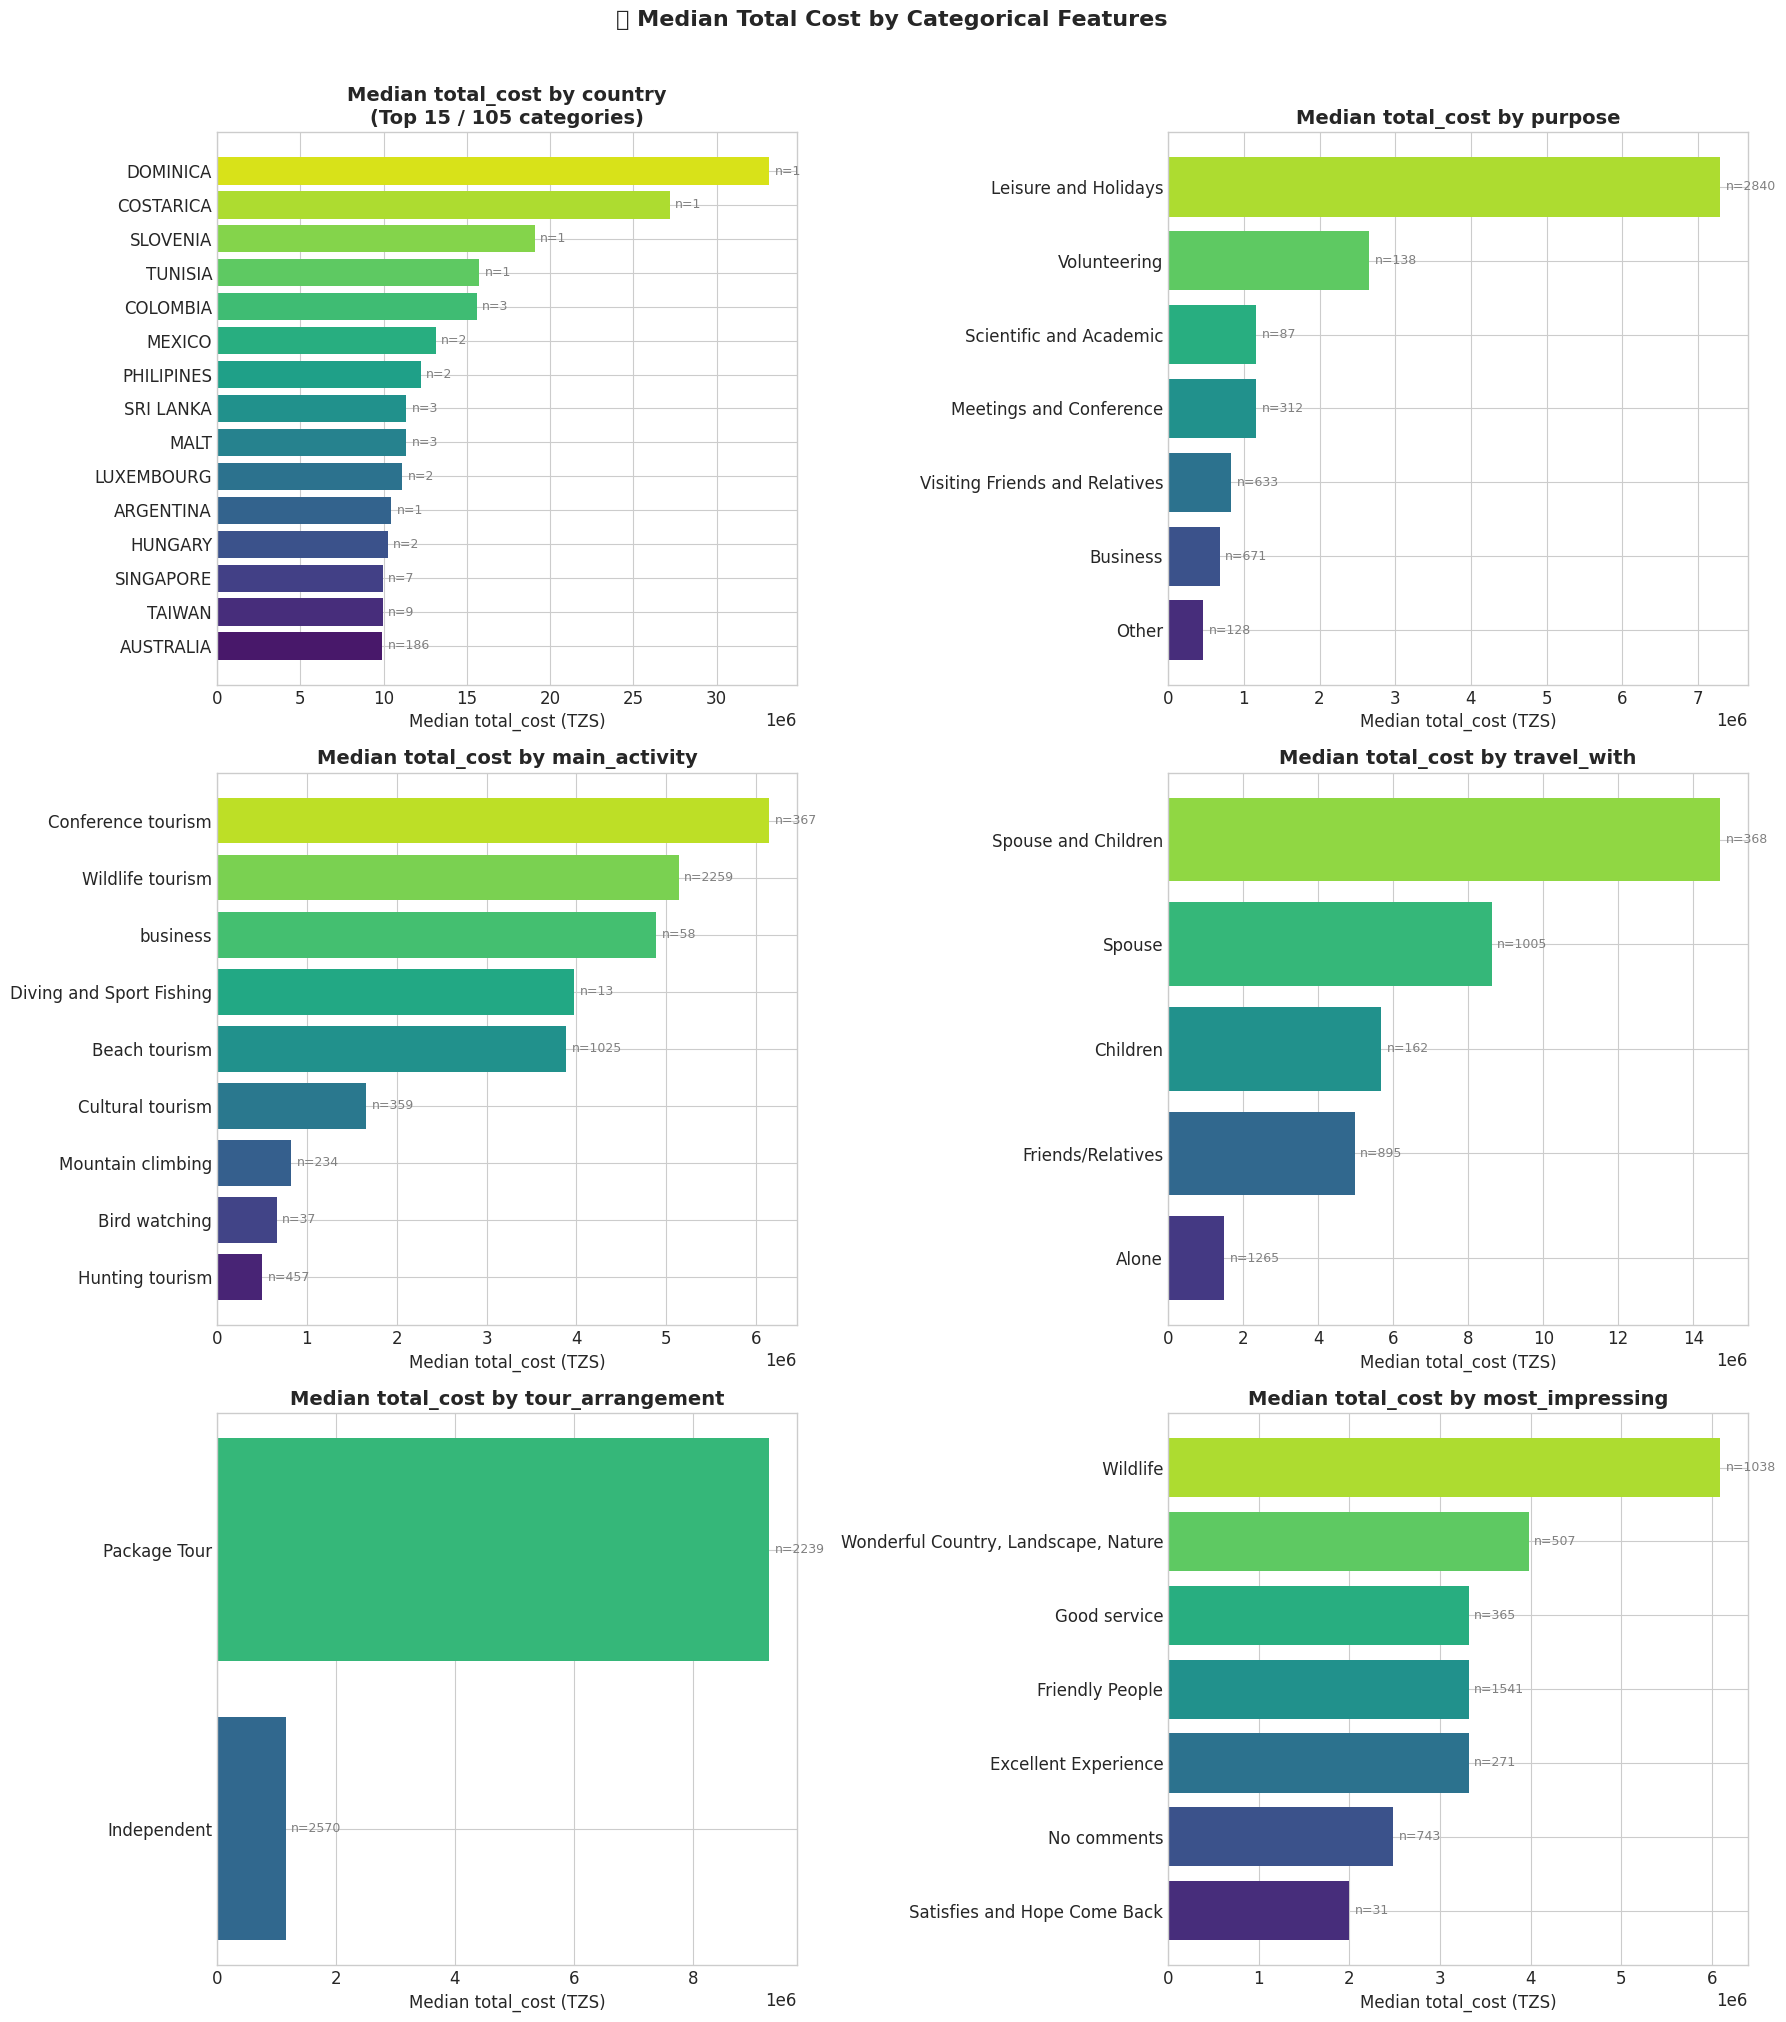


📋 Bảng tổng hợp Median Target theo tất cả Categorical Columns:


────────────────────────────────────────────────────────────
  country (105 groups)
────────────────────────────────────────────────────────────
  DOMINICA                       | median:   33,150,000 | mean:   33,150,000 | n=    1
  COSTARICA                      | median:   27,183,000 | mean:   27,183,000 | n=    1
  SLOVENIA                       | median:   19,062,372 | mean:   19,062,372 | n=    1
  TUNISIA                        | median:   15,746,250 | mean:   15,746,250 | n=    1
  COLOMBIA                       | median:   15,580,500 | mean:   13,315,250 | n=    3
  MEXICO                         | median:   13,127,400 | mean:   13,127,400 | n=    2
  PHILIPINES                     | median:   12,224,062 | mean:   12,224,062 | n=    2
  SRI LANKA                      | median:   11,353,875 | mean:   12,320,750 | n=    3
  MALT                           | median:   11,346,650 | mean:   10,402,578 | n=    3
  LUXE

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

# Chọn 6 cột quan trọng nhất để vẽ
plot_cols = ['country', 'purpose', 'main_activity', 'travel_with', 
             'tour_arrangement', 'most_impressing']

for idx, col in enumerate(plot_cols):
    ax = axes[idx]
    
    # Tính thống kê
    stats = (train.groupby(col)[TARGET]
             .agg(['median', 'mean', 'count'])
             .sort_values('median', ascending=True)
             .reset_index())
    
    # Chỉ hiển thị top 15 nếu quá nhiều
    if len(stats) > 15:
        stats = stats.tail(15)
        ax.set_title(f'Median {TARGET} by {col}\n(Top 15 / {train[col].nunique()} categories)', 
                     fontweight='bold')
    else:
        ax.set_title(f'Median {TARGET} by {col}', fontweight='bold')
    
    # Vẽ horizontal bar
    colors = sns.color_palette('viridis', len(stats))
    bars = ax.barh(stats[col].astype(str), stats['median'], color=colors)
    
    # Annotate count
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.text(row['median'] + stats['median'].max() * 0.01, i,
                f"n={int(row['count'])}", va='center', fontsize=9, color='gray')
    
    ax.set_xlabel(f'Median {TARGET} (TZS)')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(6, 6))

plt.suptitle('📊 Median Total Cost by Categorical Features', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Bảng tổng hợp tất cả cột ──
print("\n📋 Bảng tổng hợp Median Target theo tất cả Categorical Columns:\n")
for col in CAT_COLS:
    stats = (train.groupby(col)[TARGET]
             .agg(['median', 'mean', 'count'])
             .sort_values('median', ascending=False))
    print(f"\n{'─'*60}")
    print(f"  {col} ({len(stats)} groups)")
    print(f"{'─'*60}")
    for val, row in stats.iterrows():
        print(f"  {str(val):30s} | median: {row['median']:>12,.0f} | "
              f"mean: {row['mean']:>12,.0f} | n={int(row['count']):>5d}")

### 2.2 Box Plots — Phân phối Target theo Category
Sử dụng log scale vì `total_cost` có thể bị skewed mạnh.

Skewness of total_cost: 2.97
→ Rất lệch phải (right-skewed)
→ Sử dụng log10 scale cho các biểu đồ box plot.



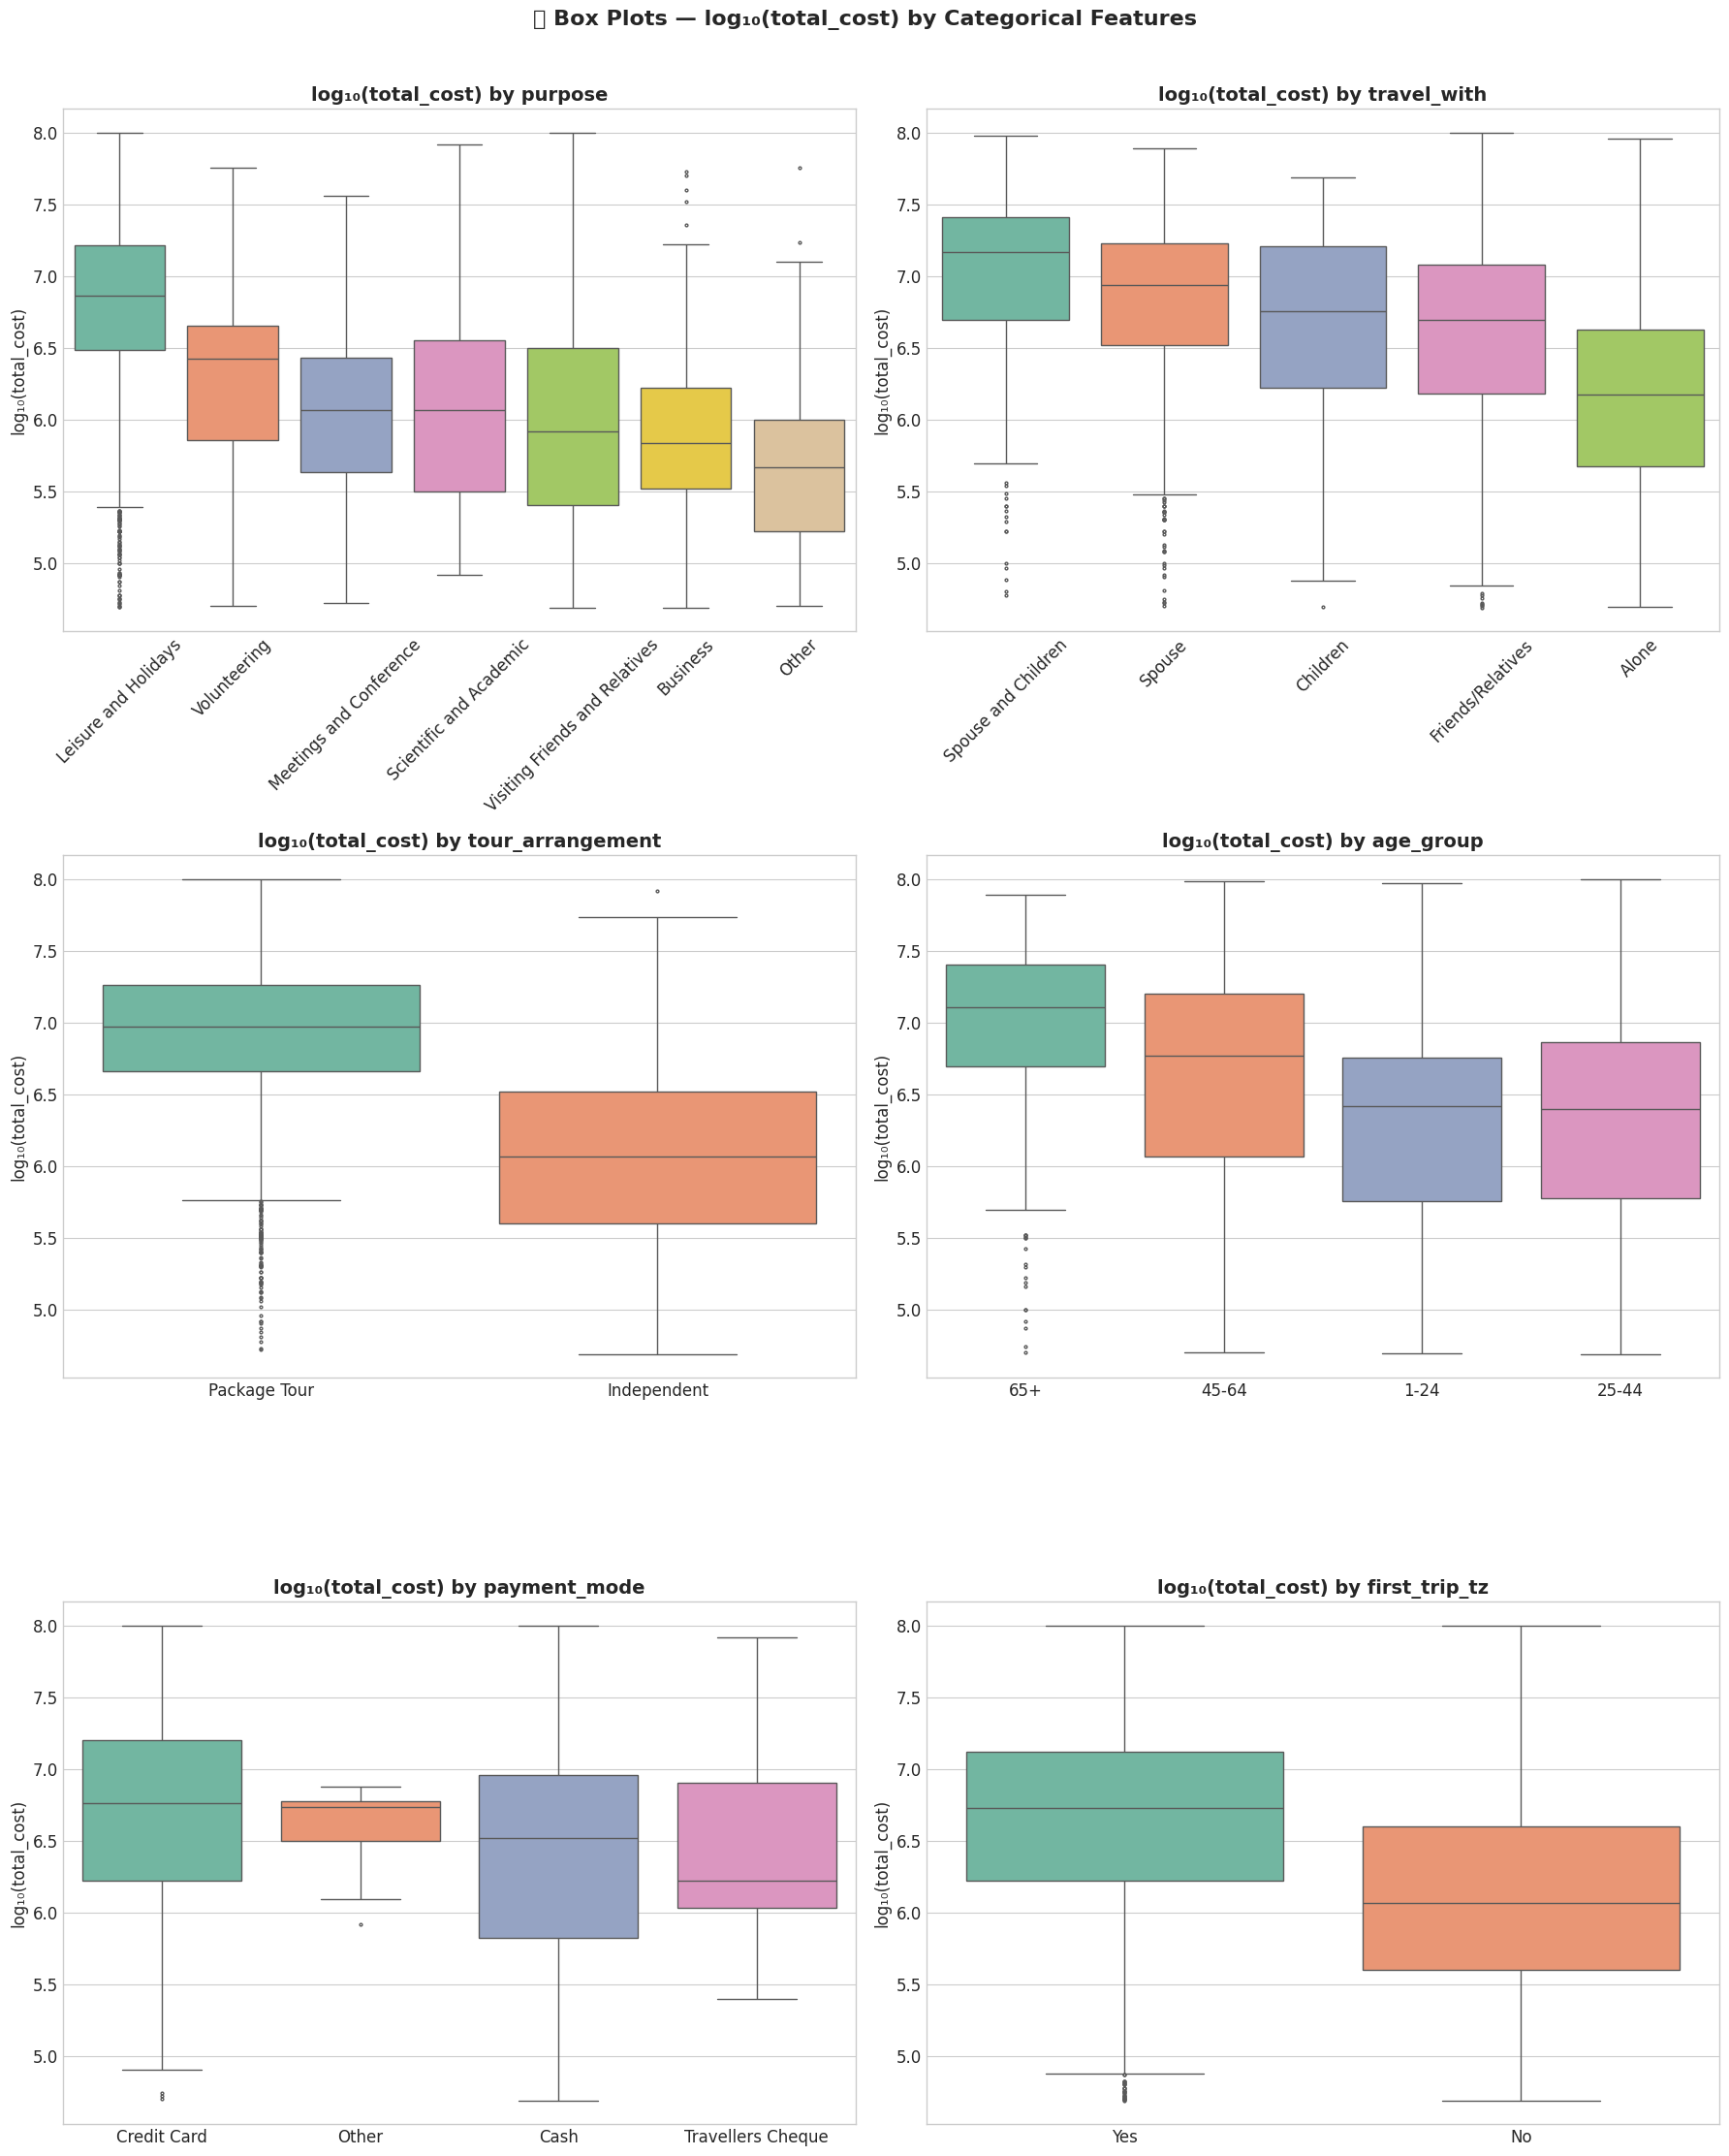

In [ ]:
# Kiểm tra skewness
skew_val = train[TARGET].skew()
print(f"Skewness of {TARGET}: {skew_val:.2f}")
print(f"→ {'Rất lệch phải (right-skewed)' if skew_val > 1 else 'Lệch vừa' if skew_val > 0.5 else 'Gần đối xứng'}")
print(f"→ Sử dụng log10 scale cho các biểu đồ box plot.\n")

# Tạo cột log
train['log_total_cost'] = np.log10(train[TARGET].clip(lower=1))

fig, axes = plt.subplots(3, 2, figsize=(18, 22))
axes = axes.flatten()

plot_cols_box = ['purpose', 'travel_with', 'tour_arrangement', 
                 'age_group', 'payment_mode', 'first_trip_tz']

for idx, col in enumerate(plot_cols_box):
    ax = axes[idx]
    
    # Sắp xếp theo median
    order = (train.groupby(col)['log_total_cost']
             .median().sort_values(ascending=False).index)
    
    sns.boxplot(data=train, x=col, y='log_total_cost', order=order, ax=ax,
                palette='Set2', showfliers=True, fliersize=2)
    
    ax.set_title(f'log₁₀(total_cost) by {col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('log₁₀(total_cost)')
    
    # Xoay label nếu cần
    if train[col].nunique() > 4:
        ax.tick_params(axis='x', rotation=45)

plt.suptitle('📦 Box Plots — log₁₀(total_cost) by Categorical Features',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Dọn dẹp cột tạm
train.drop(columns=['log_total_cost'], inplace=True)

### 2.3 Effect Size Summary
Bảng tổng hợp mức độ ảnh hưởng của mỗi categorical column lên target.

In [ ]:
effect_rows = []
for col in CAT_COLS:
    medians = train.groupby(col)[TARGET].median()
    means   = train.groupby(col)[TARGET].mean()
    counts  = train.groupby(col)[TARGET].count()
    
    effect_rows.append({
        'Column': col,
        '# Groups': len(medians),
        'Median Range': f"{medians.min():,.0f} — {medians.max():,.0f}",
        'Median Ratio (max/min)': round(medians.max() / max(medians.min(), 1), 1),
        'Highest Median Group': f"{medians.idxmax()} ({medians.max():,.0f})",
        'Lowest Median Group': f"{medians.idxmin()} ({medians.min():,.0f})",
        'Overall Median': f"{train[TARGET].median():,.0f}",
    })

effect_df = pd.DataFrame(effect_rows).sort_values('Median Ratio (max/min)', ascending=False)
display(effect_df.style.set_caption("📈 Effect Size Summary — Categorical Features on total_cost"))

print("\n📌 TOP INSIGHTS:")
top3 = effect_df.head(3)
for _, row in top3.iterrows():
    print(f"   • {row['Column']}: tỉ lệ max/min median = {row['Median Ratio (max/min)']}x")
    print(f"     Cao nhất: {row['Highest Median Group']}")
    print(f"     Thấp nhất: {row['Lowest Median Group']}")
    print()

,Column,# Groups,Median Range,Median Ratio (max/min),Highest Median Group,Lowest Median Group,Overall Median
0,country,105,"160,000 — 33,150,000",207.200000,"DOMINICA (33,150,000)","LESOTHO (160,000)","3,397,875"
3,purpose,7,"465,000 — 7,293,000",15.700000,"Leisure and Holidays (7,293,000)","Other (465,000)","3,397,875"
4,main_activity,9,"500,000 — 6,145,308",12.300000,"Conference tourism (6,145,308)","Hunting tourism (500,000)","3,397,875"
5,info_source,8,"770,738 — 7,956,000",10.300000,"Travel, agent, tour operator (7,956,000)","inflight magazines (770,738)","3,397,875"
2,travel_with,5,"1,491,750 — 14,720,606",9.900000,"Spouse and Children (14,720,606)","Alone (1,491,750)","3,397,875"
6,tour_arrangement,2,"1,155,125 — 9,282,000",8.000000,"Package Tour (9,282,000)","Independent (1,155,125)","3,397,875"
1,age_group,4,"2,486,250 — 12,845,625",5.200000,"65+ (12,845,625)","25-44 (2,486,250)","3,397,875"
8,first_trip_tz,2,"1,160,250 — 5,337,150",4.600000,"Yes (5,337,150)","No (1,160,250)","3,397,875"
7,payment_mode,4,"1,657,500 — 5,801,250",3.500000,"Credit Card (5,801,250)","Travellers Cheque (1,657,500)","3,397,875"
9,most_impressing,7,"2,000,000 — 6,091,312",3.000000,"Wildlife (6,091,312)","Satisfies and Hope Come Back (2,000,000)","3,397,875"



📌 TOP INSIGHTS:
   • country: tỉ lệ max/min median = 207.2x
     Cao nhất: DOMINICA (33,150,000)
     Thấp nhất: LESOTHO (160,000)

   • purpose: tỉ lệ max/min median = 15.7x
     Cao nhất: Leisure and Holidays (7,293,000)
     Thấp nhất: Other (465,000)

   • main_activity: tỉ lệ max/min median = 12.3x
     Cao nhất: Conference tourism (6,145,308)
     Thấp nhất: Hunting tourism (500,000)



---
## Phase 3: Đánh giá Train/Test Distribution Shift

### 3.1 Category Distribution Comparison
So sánh tỉ lệ phần trăm mỗi category giữa Train và Test.

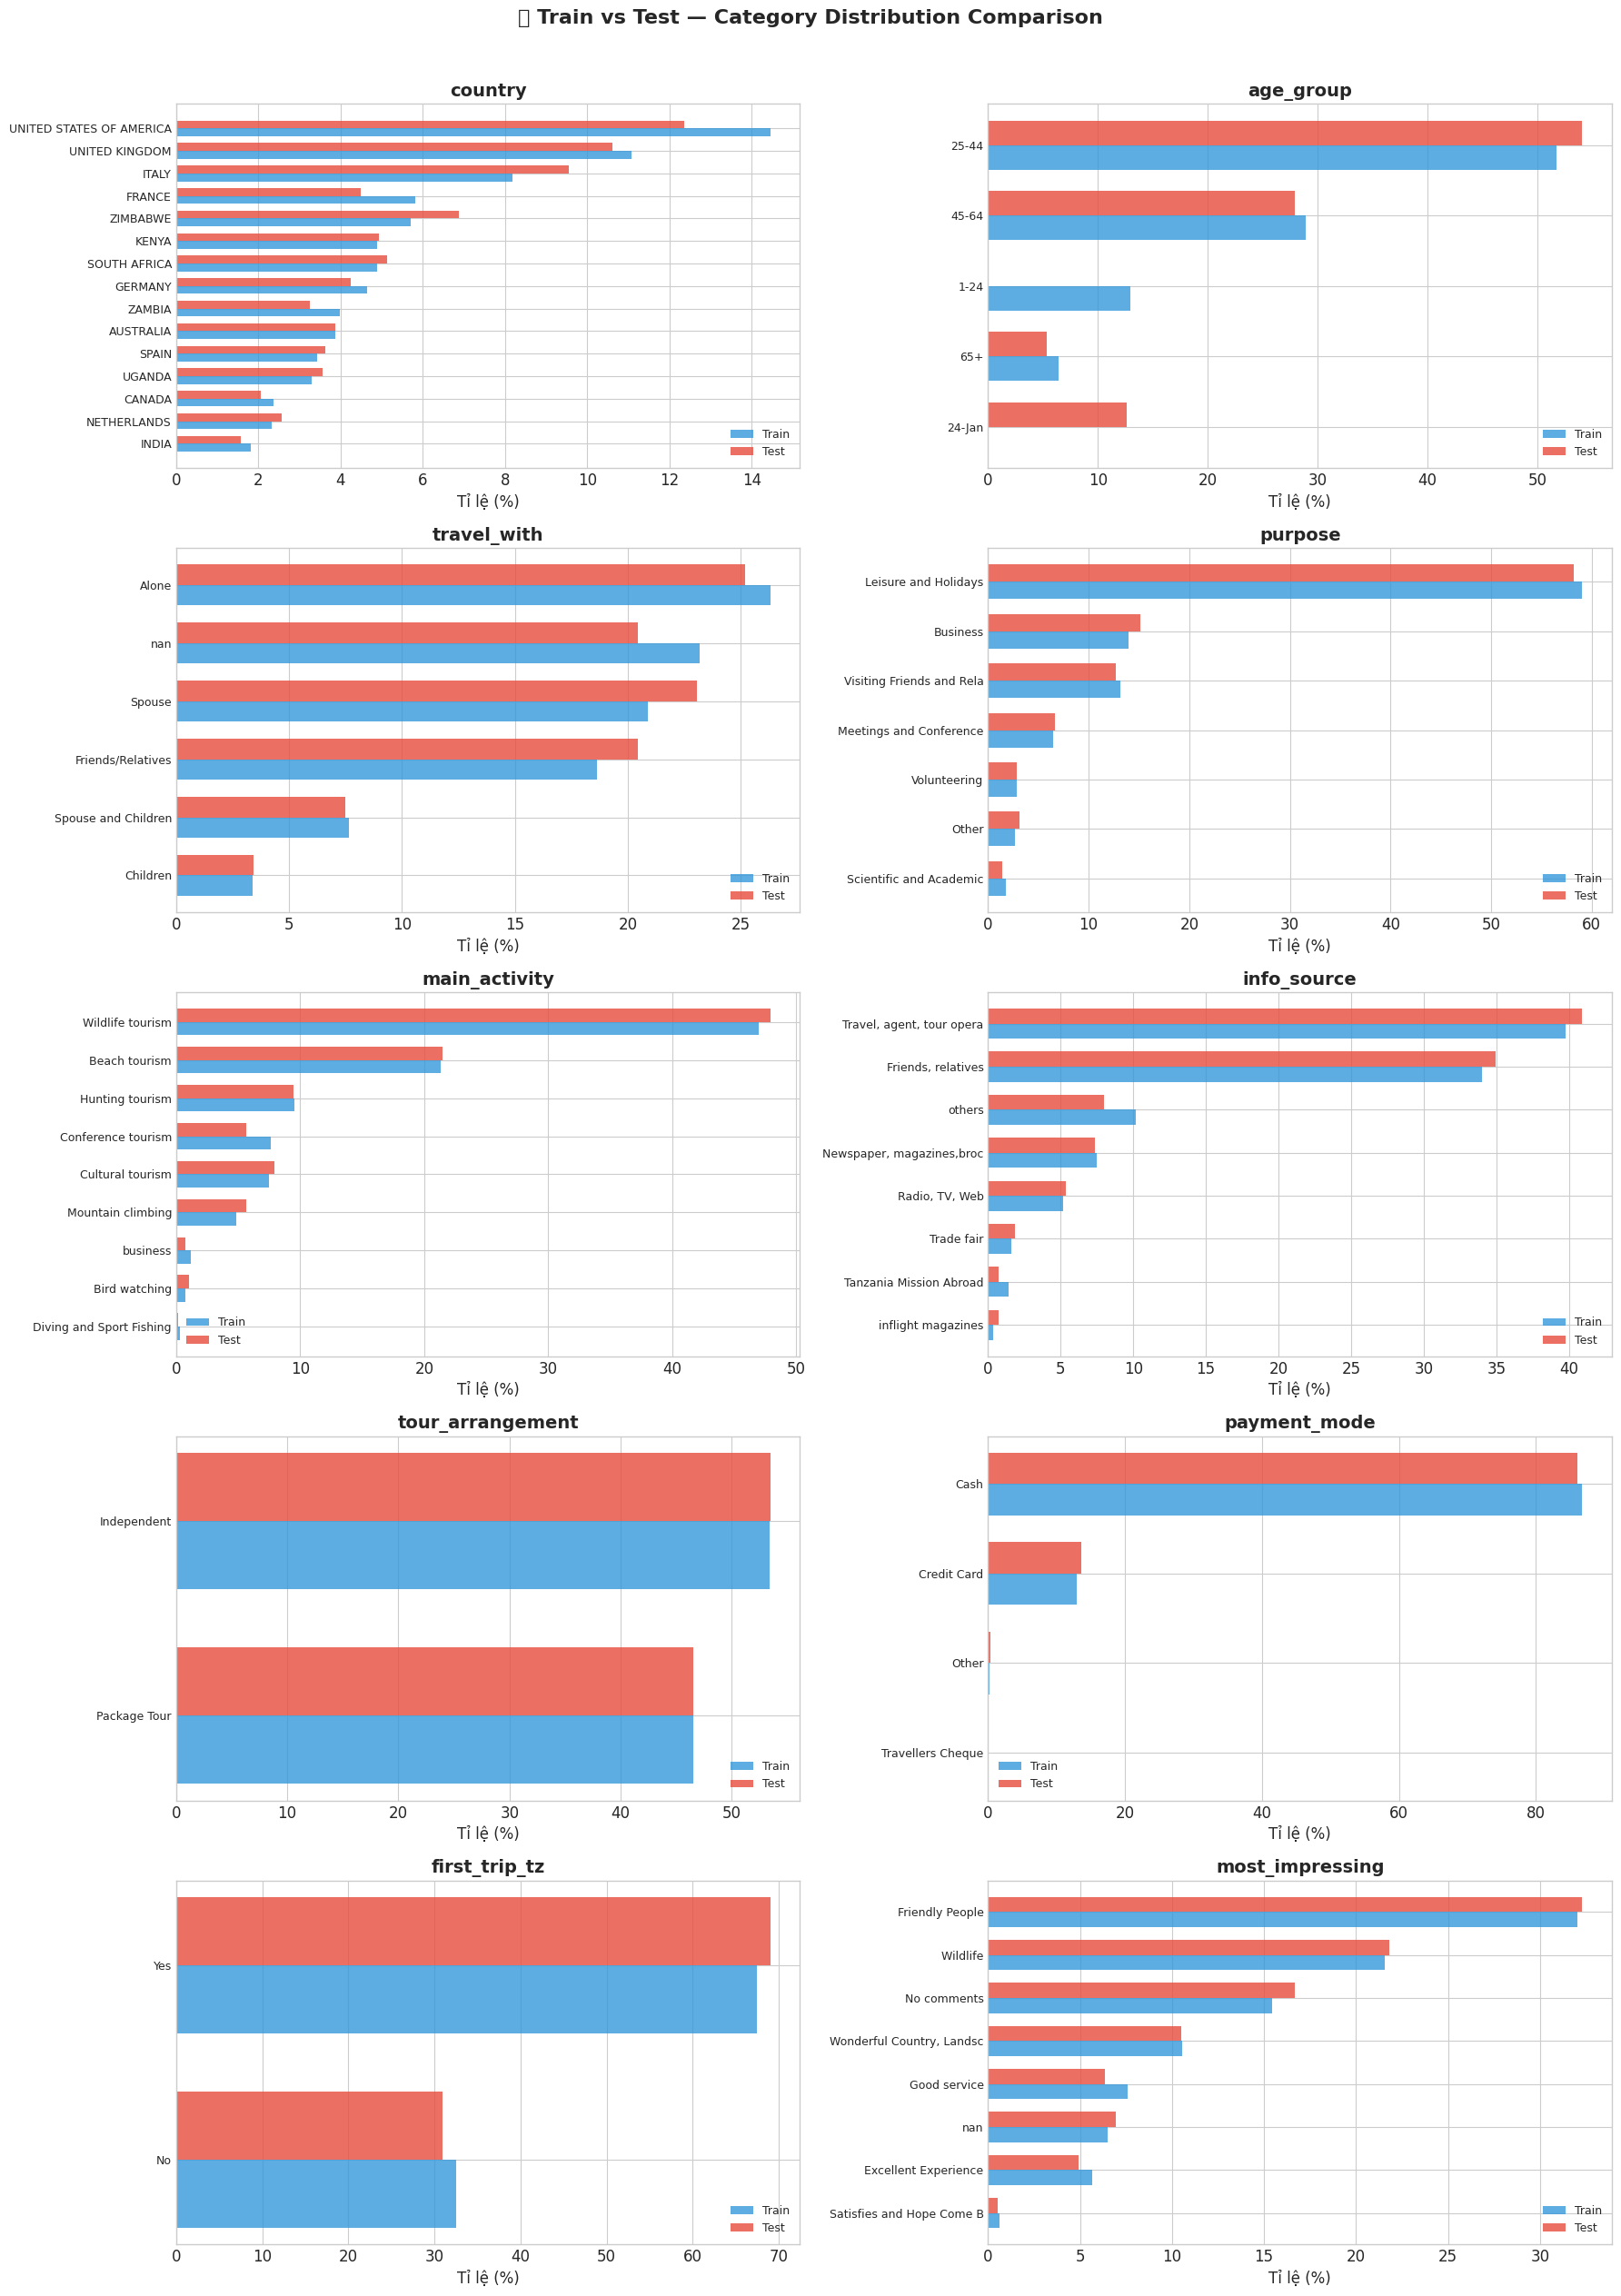

In [ ]:
n_cols = len(CAT_COLS)
n_rows_grid = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows_grid, 2, figsize=(18, 5 * n_rows_grid))
axes = axes.flatten()

for idx, col in enumerate(CAT_COLS):
    ax = axes[idx]
    
    # Tính tỉ lệ
    train_pct = train[col].value_counts(normalize=True, dropna=False).rename('Train (%)')
    test_pct  = test[col].value_counts(normalize=True, dropna=False).rename('Test (%)')
    
    # Merge
    comp = pd.concat([train_pct, test_pct], axis=1).fillna(0) * 100
    comp = comp.sort_values('Train (%)', ascending=True)
    
    # Chỉ hiển thị top 15
    if len(comp) > 15:
        comp = comp.tail(15)
    
    # Vẽ
    x = np.arange(len(comp))
    width = 0.35
    
    bars1 = ax.barh(x - width/2, comp['Train (%)'], width, label='Train', color='#3498db', alpha=0.8)
    bars2 = ax.barh(x + width/2, comp['Test (%)'],  width, label='Test',  color='#e74c3c', alpha=0.8)
    
    ax.set_yticks(x)
    ax.set_yticklabels([str(v)[:25] for v in comp.index], fontsize=9)
    ax.set_xlabel('Tỉ lệ (%)')
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(fontsize=9)

# Ẩn subplot thừa
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('📊 Train vs Test — Category Distribution Comparison',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Train-only & Test-only Categories
Xác định các giá trị chỉ xuất hiện ở một tập.

In [ ]:
shift_rows = []

for col in CAT_COLS:
    train_cats = set(train[col].dropna().unique())
    test_cats  = set(test[col].dropna().unique())
    
    train_only = train_cats - test_cats
    test_only  = test_cats - train_cats
    
    if train_only or test_only:
        # Đếm số dòng bị ảnh hưởng
        train_only_count = train[col].isin(train_only).sum() if train_only else 0
        test_only_count  = test[col].isin(test_only).sum() if test_only else 0
        
        shift_rows.append({
            'Column': col,
            'Train-only Values': ', '.join(sorted(str(v) for v in train_only)) if train_only else '—',
            'Train-only Count': train_only_count,
            'Test-only Values': ', '.join(sorted(str(v) for v in test_only)) if test_only else '—',
            'Test-only Count': test_only_count,
            'Impact': '🔴 High' if test_only_count > 50 else '🟡 Medium' if test_only_count > 10 else '🟢 Low',
        })

if shift_rows:
    shift_df = pd.DataFrame(shift_rows)
    display(shift_df.style.set_caption("⚠️ Train-only & Test-only Categories"))
    
    print("\n📌 PHÂN TÍCH:")
    for _, row in shift_df.iterrows():
        print(f"\n   {row['Column']}:")
        if row['Train-only Values'] != '—':
            print(f"      • Train-only: {row['Train-only Values']} ({row['Train-only Count']} rows)")
        if row['Test-only Values'] != '—':
            print(f"      • Test-only:  {row['Test-only Values']} ({row['Test-only Count']} rows)")
            print(f"      → Mô hình KHÔNG được huấn luyện trên các giá trị này!")
        print(f"      → Impact: {row['Impact']}")
else:
    print("✅ Không có unseen categories giữa Train và Test.")

,Column,Train-only Values,Train-only Count,Test-only Values,Test-only Count,Impact
0,country,"ALGERIA, ANGOLA, BERMUDA, BURGARIA, COLOMBIA, CROATIA, DJIBOUT, ESTONIA, GEORGIA, IRAQ, IVORY COAST, KUWAIT, LATVIA, LESOTHO, LITHUANIA, LUXEMBOURG, MADAGASCAR, MAURITIUS, MEXICO, MONTENEGRO, MYANMAR, NEPAL, NIGER, NIGERIA, SLOVENIA, SRI LANKA, THAILAND, TRINIDAD TOBACCO, TUNISIA, TURKEY, URUGUAY",57,"BANGLADESH, BOSNIA, BOTSWANA, BULGARIA, GUINEA, HAITI, JAMAICA, LIBERIA, MACEDONIA, PERU, SAUD ARABIA, SOMALI, VIETNAM",16,🟡 Medium
1,age_group,1-24,624,24-Jan,202,🔴 High



📌 PHÂN TÍCH:

   country:
      • Train-only: ALGERIA, ANGOLA, BERMUDA, BURGARIA, COLOMBIA, CROATIA, DJIBOUT, ESTONIA, GEORGIA, IRAQ, IVORY COAST, KUWAIT, LATVIA, LESOTHO, LITHUANIA, LUXEMBOURG, MADAGASCAR, MAURITIUS, MEXICO, MONTENEGRO, MYANMAR, NEPAL, NIGER, NIGERIA, SLOVENIA, SRI LANKA, THAILAND, TRINIDAD TOBACCO, TUNISIA, TURKEY, URUGUAY (57 rows)
      • Test-only:  BANGLADESH, BOSNIA, BOTSWANA, BULGARIA, GUINEA, HAITI, JAMAICA, LIBERIA, MACEDONIA, PERU, SAUD ARABIA, SOMALI, VIETNAM (16 rows)
      → Mô hình KHÔNG được huấn luyện trên các giá trị này!
      → Impact: 🟡 Medium

   age_group:
      • Train-only: 1-24 (624 rows)
      • Test-only:  24-Jan (202 rows)
      → Mô hình KHÔNG được huấn luyện trên các giá trị này!
      → Impact: 🔴 High


### 3.3 Missing Ratio Shift
So sánh tỉ lệ dữ liệu khuyết giữa hai tập.

In [ ]:
miss_rows = []
all_feature_cols = CAT_COLS + BIN_COLS + NUM_COLS

for col in all_feature_cols:
    miss_train = train[col].isna().mean() * 100
    miss_test  = test[col].isna().mean() * 100 if col in test.columns else None
    delta = abs(miss_train - miss_test) if miss_test is not None else None
    
    miss_rows.append({
        'Column': col,
        'Type': 'CAT' if col in CAT_COLS else ('BIN' if col in BIN_COLS else 'NUM'),
        'Missing Train (%)': round(miss_train, 2),
        'Missing Test (%)': round(miss_test, 2) if miss_test is not None else 'N/A',
        'Delta (%)': round(delta, 2) if delta is not None else 'N/A',
        'Alert': '🔴' if (delta is not None and delta > 5) else ('🟡' if (delta is not None and delta > 2) else ''),
    })

miss_df = pd.DataFrame(miss_rows)
display(miss_df.style.set_caption("📊 Missing Ratio Comparison — Train vs Test"))

# Highlight cột có missing đáng kể
significant_miss = miss_df[miss_df['Missing Train (%)'] > 0]
if len(significant_miss) > 0:
    print("\n📌 Cột có dữ liệu khuyết:")
    for _, row in significant_miss.iterrows():
        print(f"   • {row['Column']} ({row['Type']}): Train={row['Missing Train (%)']}%, "
              f"Test={row['Missing Test (%)']}%, Delta={row['Delta (%)']}% {row['Alert']}")
else:
    print("✅ Không có cột nào bị missing đáng kể.")

,Column,Type,Missing Train (%),Missing Test (%),Delta (%),Alert
0,country,CAT,0.000000,0.000000,0.000000,
1,age_group,CAT,0.000000,0.000000,0.000000,
2,travel_with,CAT,23.160000,20.420000,2.740000,🟡
3,purpose,CAT,0.000000,0.000000,0.000000,
4,main_activity,CAT,0.000000,0.000000,0.000000,
5,info_source,CAT,0.000000,0.000000,0.000000,
6,tour_arrangement,CAT,0.000000,0.000000,0.000000,
7,payment_mode,CAT,0.000000,0.000000,0.000000,
8,first_trip_tz,CAT,0.000000,0.000000,0.000000,
9,most_impressing,CAT,6.510000,6.930000,0.420000,



📌 Cột có dữ liệu khuyết:
   • travel_with (CAT): Train=23.16%, Test=20.42%, Delta=2.74% 🟡
   • most_impressing (CAT): Train=6.51%, Test=6.93%, Delta=0.42% 
   • total_female (NUM): Train=0.06%, Test=0.06%, Delta=0.0% 
   • total_male (NUM): Train=0.1%, Test=0.12%, Delta=0.02% 


### 3.4 Shift Impact Assessment

#### 📋 Đánh giá tổng hợp tác động của Train/Test Shift:

**Các vấn đề phát hiện:**
1. **Unseen categories trong Test:** Nếu tồn tại, mô hình sẽ gặp lỗi khi dự đoán trên các giá trị này.
   - → **Giải pháp:** Gom nhóm các rare categories thành "Other" TRƯỚC khi train, đảm bảo cả hai tập đều có nhóm "Other".
2. **Distribution shift:** Một số category thay đổi tỉ lệ đáng kể giữa Train/Test.
   - → **Giải pháp:** Sử dụng **Stratified K-Fold** dựa trên các cột có shift lớn nhất.
3. **Missing ratio shift:** Nếu tỉ lệ missing khác biệt lớn, chiến lược imputation cần nhất quán.
   - → **Giải pháp:** Fit imputer trên Train, transform cả Test.

#### 🎯 Đề xuất Validation Strategy:
- Sử dụng **StratifiedKFold (k=5)** dựa trên cột có phân phối ổn định nhất (ví dụ: `purpose` hoặc `tour_arrangement`).
- Kết hợp với **GroupKFold** nếu có thông tin nhóm (ví dụ: `country`).
- Luôn kiểm tra unseen categories trên fold validation trước khi áp dụng lên Test.

---
## Phase 4: Tổng hợp Deliverables

In [ ]:
print("=" * 70)
print("📋 DELIVERABLE 1: DANH SÁCH CỘT VÀ PHƯƠNG PHÁP MÃ HÓA")
print("=" * 70)

# ── Bảng 1: One-Hot Encoding ──
onehot_cols = []
for col in CAT_COLS:
    nunique = train[col].nunique()
    vc = train[col].value_counts(normalize=True)
    rare_count = (vc < 0.01).sum()
    
    # Xác định có cần gom rare không
    if rare_count > 0:
        effective_cats = nunique - rare_count + 1  # +1 cho "Other"
        note = f"Gom {rare_count} rare → 'Other', rồi One-Hot ({effective_cats} cột)"
    else:
        effective_cats = nunique
        note = f"One-Hot trực tiếp ({effective_cats} cột)"
    
    # Bỏ qua nếu là ordinal/binary
    if col in ['age_group', 'first_trip_tz']:
        continue
    
    onehot_cols.append({
        'Column': col,
        'Original Categories': nunique,
        'Rare Categories (<1%)': rare_count,
        'Encoding Plan': note,
        'Expected Columns After': effective_cats,
    })

onehot_df = pd.DataFrame(onehot_cols)
display(onehot_df.style.set_caption("📊 Bảng 1: Cột áp dụng One-Hot Encoding"))

# ── Bảng 2: Ordinal / Binary ──
print("\n")
ordbin_data = [
    {'Column': 'age_group', 'Encoding': 'Ordinal', 
     'Mapping': '1-24→0, 25-44→1, 45-64→2, 65+→3',
     'Note': 'Sửa "24-Jan"→"1-24" trong Test trước'},
    {'Column': 'first_trip_tz', 'Encoding': 'Binary', 
     'Mapping': 'No→0, Yes→1', 'Note': ''},
]
for col in BIN_COLS:
    ordbin_data.append({
        'Column': col, 'Encoding': 'Binary',
        'Mapping': 'No→0, Yes→1', 'Note': 'Package indicator'
    })

ordbin_df = pd.DataFrame(ordbin_data)
display(ordbin_df.style.set_caption("📊 Bảng 2: Cột áp dụng Ordinal / Binary Encoding"))

# ── Tổng hợp Expected Dimensions ──
total_new_cols = onehot_df['Expected Columns After'].sum() + len(ordbin_df) + len(NUM_COLS)
print(f"\n📊 Tổng số features dự kiến sau encoding: {int(total_new_cols)}")
print(f"   • One-Hot: {int(onehot_df['Expected Columns After'].sum())} cột")
print(f"   • Ordinal/Binary: {len(ordbin_df)} cột")
print(f"   • Numerical: {len(NUM_COLS)} cột")

📋 DELIVERABLE 1: DANH SÁCH CỘT VÀ PHƯƠNG PHÁP MÃ HÓA


,Column,Original Categories,Rare Categories (<1%),Encoding Plan,Expected Columns After
0,country,105,85,"Gom 85 rare → 'Other', rồi One-Hot (21 cột)",21
1,travel_with,5,0,One-Hot trực tiếp (5 cột),5
2,purpose,7,0,One-Hot trực tiếp (7 cột),7
3,main_activity,9,2,"Gom 2 rare → 'Other', rồi One-Hot (8 cột)",8
4,info_source,8,1,"Gom 1 rare → 'Other', rồi One-Hot (8 cột)",8
5,tour_arrangement,2,0,One-Hot trực tiếp (2 cột),2
6,payment_mode,4,2,"Gom 2 rare → 'Other', rồi One-Hot (3 cột)",3
7,most_impressing,7,1,"Gom 1 rare → 'Other', rồi One-Hot (7 cột)",7


,Column,Encoding,Mapping,Note
0,age_group,Ordinal,"1-24→0, 25-44→1, 45-64→2, 65+→3","Sửa ""24-Jan""→""1-24"" trong Test trước"
1,first_trip_tz,Binary,"No→0, Yes→1",
2,package_transport_int,Binary,"No→0, Yes→1",Package indicator
3,package_accomodation,Binary,"No→0, Yes→1",Package indicator
4,package_food,Binary,"No→0, Yes→1",Package indicator
5,package_transport_tz,Binary,"No→0, Yes→1",Package indicator
6,package_sightseeing,Binary,"No→0, Yes→1",Package indicator
7,package_guided_tour,Binary,"No→0, Yes→1",Package indicator
8,package_insurance,Binary,"No→0, Yes→1",Package indicator



📊 Tổng số features dự kiến sau encoding: 74
   • One-Hot: 61 cột
   • Ordinal/Binary: 9 cột
   • Numerical: 4 cột


In [ ]:
print("=" * 70)
print("📋 DELIVERABLE 2: KẾ HOẠCH GOM NHÓM RARE CATEGORIES")
print("=" * 70)

for col in CAT_COLS:
    vc = train[col].value_counts(normalize=True)
    rare_mask = vc < 0.01
    
    if rare_mask.any():
        rare_vals = vc[rare_mask]
        total_rare_pct = rare_vals.sum() * 100
        
        print(f"\n{'─'*60}")
        print(f"  📌 {col}")
        print(f"{'─'*60}")
        print(f"  Threshold: < 1% → gom vào 'Other'")
        print(f"  Số category bị gom: {len(rare_vals)}")
        print(f"  Tổng tỉ lệ bị gom: {total_rare_pct:.2f}%")
        print(f"  Chi tiết:")
        for val, pct in rare_vals.items():
            print(f"    • '{val}': {pct*100:.2f}% ({int(pct * len(train))} rows)")

print(f"\n{'═'*70}")
print(f"💡 LƯU Ý: Áp dụng CÙNG mapping gom nhóm cho cả Train và Test!")
print(f"   Code: df[col] = df[col].apply(lambda x: x if x in keep_list else 'Other')")
print(f"{'═'*70}")

📋 DELIVERABLE 2: KẾ HOẠCH GOM NHÓM RARE CATEGORIES

────────────────────────────────────────────────────────────
  📌 country
────────────────────────────────────────────────────────────
  Threshold: < 1% → gom vào 'Other'
  Số category bị gom: 85
  Tổng tỉ lệ bị gom: 13.14%
  Chi tiết:
    • 'DENMARK': 0.85% (41 rows)
    • 'RWANDA': 0.83% (40 rows)
    • 'SWEDEN': 0.77% (37 rows)
    • 'OMAN': 0.73% (35 rows)
    • 'UAE': 0.69% (33 rows)
    • 'DRC': 0.62% (30 rows)
    • 'IRELAND': 0.60% (29 rows)
    • 'MALAYSIA': 0.48% (23 rows)
    • 'NORWAY': 0.44% (21 rows)
    • 'MALAWI': 0.42% (20 rows)
    • 'AUSTRIA': 0.37% (18 rows)
    • 'NEW ZEALAND': 0.37% (18 rows)
    • 'ISRAEL': 0.33% (16 rows)
    • 'POLAND': 0.33% (16 rows)
    • 'UNITED ARAB EMIRATES': 0.27% (13 rows)
    • 'KOREA': 0.25% (12 rows)
    • 'CONGO': 0.23% (11 rows)
    • 'CZECH REPUBLIC': 0.23% (11 rows)
    • 'BRAZIL': 0.21% (10 rows)
    • 'EGYPT': 0.21% (10 rows)
    • 'PORTUGAL': 0.21% (10 rows)
    • 'TAIWAN': 0.

---
## 📝 Final Summary & Next Steps

### Tóm tắt phát hiện chính:

| # | Phát hiện | Tác động | Hành động |
|---|-----------|----------|-----------|
| 1 | File `VariableDefinitions.csv` có typo tên cột (`infor_source`, `tour_arrangment`) nhưng CSV thực tế dùng tên đúng | Không ảnh hưởng model | Dùng tên đúng từ CSV: `info_source`, `tour_arrangement` |
| 2 | `age_group` có giá trị "24-Jan" trong Test | ⚠️ Lỗi dữ liệu nghiêm trọng | Map "24-Jan" → "1-24" |
| 3 | `country` có "SWIZERLAND" (typo) | Nhỏ nhưng nên fix | Map "SWIZERLAND" → "SWITZERLAND" |
| 4 | Một số country chỉ có trong Train hoặc Test | Unseen category risk | Gom rare countries → "Other" |
| 5 | `total_cost` skewed mạnh | Ảnh hưởng OLS | Cân nhắc log-transform target |

### Next Steps cho Pipeline:
1. **Data Cleaning:** Fix typo (`age_group`, `country`), handle missing values.
2. **Feature Engineering:** Áp dụng encoding plan ở trên.
3. **Baseline Model:** OLS regression trên dữ liệu đã encode.
4. **Validation:** StratifiedKFold (k=5) dựa trên `purpose` hoặc `tour_arrangment`.